# Data Loading

This notebook loads the ISIC 2019 skin lesion dataset and examines its structure. We will understand the data format, file organization, and prepare for subsequent analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os
from pathlib import Path
import glob
import json

In [2]:
PROJECT_ROOT = Path("../").resolve()
with open(PROJECT_ROOT / "config.json", "r") as f:
    CONFIG = json.load(f)
    
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"

## Dataset Download Instructions

The ISIC 2019 Challenge dataset needs to be downloaded from the official source. Place the following in `data/raw/`:

1. `ISIC_2019_Training_Input/` - folder containing dermoscopic images
2. `ISIC_2019_Training_GroundTruth.csv` - labels for each image

In [5]:
# Update this path to your actual data location
IMAGES_DIR_SEGMENTATION = RAW_DATA_DIR / "segmentation" / "ISIC_2019_Training_Input"
IMAGES_DIR_CLASSIFICATION = RAW_DATA_DIR / "classification" / "ISIC2019_Training_Input"
LABELS_PATH = RAW_DATA_DIR / "classification" / "ISIC_2019_Training_GroundTruth.csv"

In [6]:
images_exist = IMAGES_DIR_CLASSIFICATION.exists()
labels_exist = LABELS_PATH.exists()

print(f"Images directory exists: {images_exist}")
print(f"Labels file exists: {labels_exist}")



Images directory exists: True
Labels file exists: True


In [7]:
df_labels = pd.read_csv(LABELS_PATH)
print(f"Labels dataframe shape: {df_labels.shape}")
print(f"\nColumn names: {df_labels.columns.tolist()}")

Labels dataframe shape: (10015, 8)

Column names: ['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [8]:
df_labels.head(10)

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,ISIC_0024311,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,ISIC_0024312,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,ISIC_0024313,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8,ISIC_0024314,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9,ISIC_0024315,1.0,0.0,0.0,0.0,0.0,0.0,0.0


The labels are in one-hot encoded format. Each column (MEL, NV, BCC, etc.) contains a binary value indicating the diagnosis.

In [9]:
df_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  object 
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), object(1)
memory usage: 626.1+ KB


In [10]:
class_columns = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]
    
# Verify one-hot encoding: each row should have exactly one 1
row_sums = df_labels[class_columns].sum(axis=1)
print(f"Rows with sum == 1: {(row_sums == 1).sum()}")
print(f"Rows with sum != 1: {(row_sums != 1).sum()}")

Rows with sum == 1: 10015
Rows with sum != 1: 0


All rows have exactly one class label, confirming proper one-hot encoding and single-label classification.

In [11]:
def get_class_label(row, class_columns):
    """Extract class name from one-hot encoded row."""
    for col in class_columns:
        if row[col] == 1:
            return col
    return None

df_labels["class_label"] = df_labels.apply(
    lambda row: get_class_label(row, class_columns), axis=1
)
df_labels[["image", "class_label"]].head(10)

,image,class_label
0,ISIC_0024306,NV
1,ISIC_0024307,NV
2,ISIC_0024308,NV
3,ISIC_0024309,NV
4,ISIC_0024310,MEL
5,ISIC_0024311,NV
6,ISIC_0024312,BKL
7,ISIC_0024313,MEL
8,ISIC_0024314,NV
9,ISIC_0024315,MEL


In [12]:
class_distribution = df_labels["class_label"].value_counts()
print("Class Distribution:")
print(class_distribution)

Class Distribution:
class_label
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115
Name: count, dtype: int64


Significant class imbalance is observed. NV (Melanocytic Nevus) dominates the dataset while classes like DF and VASC are underrepresented. This imbalance will need to be addressed during model training.

In [13]:
image_files = list(IMAGES_DIR_CLASSIFICATION.glob("*.jpg"))
print(f"Number of image files found: {len(image_files)}")
    
if image_files:
    print(f"\nSample filenames:")
    for f in image_files[:5]:
        print(f"  {f.name}")

Number of image files found: 10015

Sample filenames:
  ISIC_0024306.jpg
  ISIC_0024307.jpg
  ISIC_0024308.jpg
  ISIC_0024309.jpg
  ISIC_0024310.jpg


In [14]:
image_names_from_files = {f.stem for f in image_files}
image_names_from_labels = set(df_labels["image"])
    
matching = len(image_names_from_files & image_names_from_labels)
only_in_files = len(image_names_from_files - image_names_from_labels)
only_in_labels = len(image_names_from_labels - image_names_from_files)
    
print(f"Images matching labels: {matching}")
print(f"Images only in files: {only_in_files}")
print(f"Images only in labels: {only_in_labels}")

Images matching labels: 10015
Images only in files: 0
Images only in labels: 0


In [15]:
sample_image_path = image_files[0]
sample_image = cv2.imread(str(sample_image_path))
sample_image_rgb = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)
    
print(f"Image path: {sample_image_path.name}")
print(f"Image shape: {sample_image.shape}")
print(f"Data type: {sample_image.dtype}")
print(f"Min pixel value: {sample_image.min()}")
print(f"Max pixel value: {sample_image.max()}")

Image path: ISIC_0024306.jpg
Image shape: (450, 600, 3)
Data type: uint8
Min pixel value: 14
Max pixel value: 255


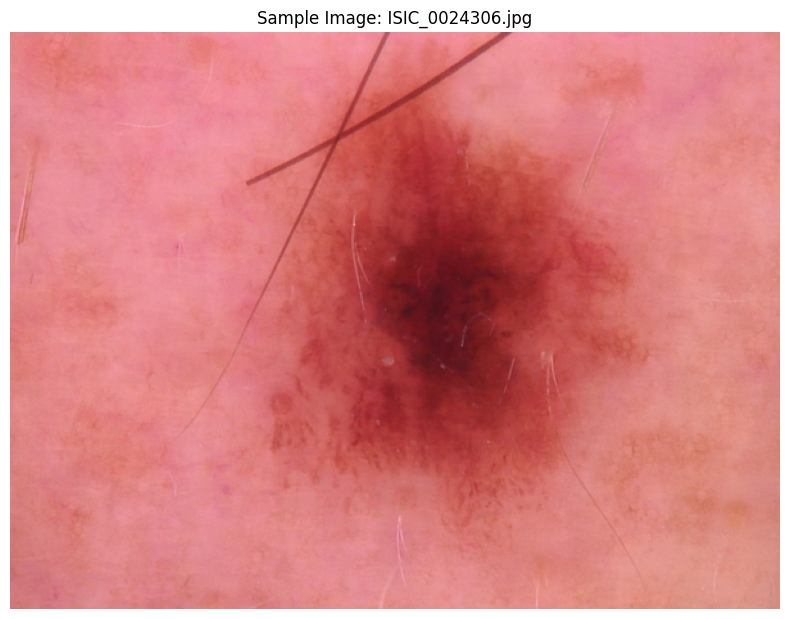

In [16]:
plt.figure(figsize=(8, 8))
plt.imshow(sample_image_rgb)
plt.title(f"Sample Image: {sample_image_path.name}")
plt.axis("off")
plt.tight_layout()
plt.show()

In [17]:
df_labels.to_csv(DATA_DIR / "labels_with_class.csv", index=False)

In [18]:
data_summary = {
    "total_images": len(image_files),
    "total_labels": len(df_labels),
    "num_classes": len(class_columns),
    "class_columns": class_columns
}

data_summary["class_distribution"] = {k: int(v) for k, v in class_distribution.items()}

with open(DATA_DIR / "data_summary.json", "w") as f:
    json.dump(data_summary, f, indent=2)
    
print("Data summary saved.")

Data summary saved.
